# Lab: Visualizing Text Data

Online reviews contain information that cannot be summarized directly until we decide what evidence to extract from the text. In this lab, you will compare historical high- and low-rated visitor reviews of Universal Studios Florida.

Ratings tell us whether visitors evaluated their experiences favorably. The review text can help us investigate what visitors chose to discuss, while review length gives us a simple quantitative feature calculated from text.

## Learning goals

By the end of this lab, you should be able to:

- prepare review text for analysis;
- convert text into word-frequency and review-length features;
- create and interpret word clouds, frequency bar charts, and a box plot;
- compare text-derived evidence across groups; and
- explain important limits of review and word-frequency data.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The local dataset is a fixed random sample of 3,000 English-language reviews of Universal Studios Florida. It was prepared from the CC0 *Reviews of Universal Studios* dataset published on Kaggle. Duplicate reviews and reviewer names were removed. The reviews extend from February 2004 through May 2021, so they describe historical visitor experiences rather than current park conditions.

The sample retains the unequal rating distribution found in the source data. A much larger number of reviews have ratings of four or five stars than ratings of one or two stars.

# Step 1: Question

> **How did high- and low-rated Universal Studios Florida reviews differ in their commonly used words and review lengths?**

For this analysis:

- **Low-rated reviews** have ratings of one or two stars.
- **High-rated reviews** have ratings of four or five stars.
- Three-star reviews are treated as neutral and are not included in the comparison.

**What topics or words do you predict will be especially common in low-rated reviews?**

Your answer: Long, Hot, Time, Wasted, Expensive, Lines, Crowded, Prices

**Do you predict that low- or high-rated reviews will generally be longer?**

Your answer:Low rated reviews will generally be higher.

# Step 2: Data

## Install WordCloud if needed

`wordcloud` is not included automatically in every Python environment. If you have not installed it in the current environment, run the next cell before importing the libraries. You normally need to install it only once for an environment.

If it is already installed, the command will confirm that the requirement is satisfied.

In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


## 1. Import the libraries

The specialized imports for regular expressions, word counts, stopwords, and word clouds are provided. Complete the following code cell by importing Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.

In [2]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

# Import Pandas, Matplotlib's pyplot, and Seaborn below.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Read the data

Read `data/universal_orlando_reviews_sample.csv` into a DataFrame named `reviews`. Use `parse_dates=["review_date"]`.

In [3]:
# Write your code here.
reviews = pd.read_csv('data/universal_orlando_reviews_sample.csv', parse_dates=["review_date"])

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [4]:
# Write your code here.
reviews.head()

,review_id,rating,review_text,review_date
0,1,5.0,"If you visit Orlando, you have to take two day...",2004-02-17
1,2,5.0,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",2004-07-06
2,3,1.0,Went to universal this september. What a waste...,2004-10-25
3,4,5.0,I think these parks (Universal Studios and Isl...,2005-01-03
4,5,1.0,"3 hours to get on a ride, $5 icees and $7 for ...",2005-03-31


In [5]:
reviews.tail()

,review_id,rating,review_text,review_date
2995,2996,1.0,TLDR; They don’t observe or enforce Covid safe...,2021-04-28
2996,2997,1.0,I've been waiting multiple DAYS on the phone t...,2021-05-04
2997,2998,1.0,✅ $850💵 + ⏰ hours of high heat 91 degrees🔥 & 😷...,2021-05-04
2998,2999,3.0,My husband and I visited Universal a couple ye...,2021-05-06
2999,3000,5.0,Harry Potter world was especially awesome and ...,2021-05-15


In [6]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    3000 non-null   int64         
 1   rating       3000 non-null   float64       
 2   review_text  3000 non-null   str           
 3   review_date  3000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 2.0 MB


In [7]:
reviews.isnull().sum()

review_id      0
rating         0
review_text    0
review_date    0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `review_id` | Course-dataset identifier for a review |
| `rating` | Visitor rating from one to five stars |
| `review_text` | Written visitor review |
| `review_date` | Calendar date associated with the review |

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `review_id` | Identifier | int64 | 0 |
| `rating` | Ordinal Categorical | float64 | 0 |
| `review_text` | Qualitative | string | 0 |
| `review_date` | Time series | datetime64 | 0 |

**What does one row represent?**

Your answer:One row represents a customer review for Universal Studios on a given day 

**What population can this dataset help us understand?**

Your answer:This populus can help us understand the painpoints and the positives of the park especially on a given day, month, or year

# Step 3: Operation

## 4. Create rating groups

Use `pd.cut()` to create `rating_group` from `rating` with:

- `bins=[0, 2, 3, 5]`; and
- `labels=["Low (1–2)", "Neutral (3)", "High (4–5)"]`.

Then display the frequency of each group in rating order. The intervals created by these bins place ratings greater than 0 through 2 in Low, greater than 2 through 3 in Neutral, and greater than 3 through 5 in High.

In [8]:
# Write your code here.
bins = [0,2,3,5]
labels = ["Low (1–2)", "Neutral (3)", "High (4–5)"]

rating_group = pd.cut(reviews["rating"], bins, labels=labels)

reviews['rating_group'] = rating_group

## 5. Select the comparison groups

Create `comparison` containing reviews whose `rating_group` is not `Neutral (3)`. Use `.copy()` because you will add calculated features to this new DataFrame.

In [9]:
# Write your code here.
comparison = reviews[reviews['rating_group']!='Neutral (3)'].copy()

comparison

,review_id,rating,review_text,review_date,rating_group
0,1,5.0,"If you visit Orlando, you have to take two day...",2004-02-17,High (4–5)
1,2,5.0,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",2004-07-06,High (4–5)
2,3,1.0,Went to universal this september. What a waste...,2004-10-25,Low (1–2)
3,4,5.0,I think these parks (Universal Studios and Isl...,2005-01-03,High (4–5)
4,5,1.0,"3 hours to get on a ride, $5 icees and $7 for ...",2005-03-31,Low (1–2)
...,...,...,...,...,...
2993,2994,1.0,This is a review of customer service. Holy hec...,2021-04-12,Low (1–2)
2995,2996,1.0,TLDR; They don’t observe or enforce Covid safe...,2021-04-28,Low (1–2)
2996,2997,1.0,I've been waiting multiple DAYS on the phone t...,2021-05-04,Low (1–2)
2997,2998,1.0,✅ $850💵 + ⏰ hours of high heat 91 degrees🔥 & 😷...,2021-05-04,Low (1–2)


**Why are three-star reviews excluded from this particular comparison?**

Your answer: Because they are considered neutral and will not convey meaning compared to those who have rated them higher or lower (having stronger feelings)

## 6. Calculate review length

Create `review_length_words` by applying `.str.split()` to `review_text` and then using `.str.len()` to count the resulting words in each review.

The first `.str` gives access to string methods for every value in the Series. After splitting, each row contains a list of words; the second `.str.len()` counts the items in each list.

In [10]:
# Write your code here.
comparison['review_length_words'] = comparison["review_text"].str.split().str.len()

## 7. Prepare the words

Run the provided code below. The `tokenize()` function:

1. converts text to lowercase;
2. uses the regular expression `[a-z']+` to find sequences of letters and apostrophes;
3. removes short words and common English stopwords; and
4. removes `park`, `parks`, `universal`, `orlando`, `studio`, `studios`, `just`, `like`, `went`, and `got` because they are generic or describe nearly every review and would distract from more informative terms.

We intentionally retain `ride` and `rides`. What visitors say about rides may help distinguish positive and negative experiences.

The function returns a list of cleaned words called **tokens**. `.map(tokenize)` applies the function to each review. `.str.join(" ")` joins each review's tokens into cleaned text for the word clouds.

In [11]:
additional_stopwords = {
    "park", "parks", "universal", "orlando", "studio", "studios",
    "just", "like", "went", "got"
}
stop_words = set(ENGLISH_STOP_WORDS) | additional_stopwords


def tokenize(text):
    words = re.findall(r"[a-z']+", text.lower())
    return [
        word
        for word in words
        if len(word) > 2 and word not in stop_words
    ]


comparison["tokens"] = comparison["review_text"].map(tokenize)
comparison["clean_text"] = comparison["tokens"].str.join(" ")

# Step 4: Check

## 8. Check the calculated features

Display:

- the number of reviews in each comparison group;
- missing-value counts for `rating_group`, `review_length_words`, `tokens`, and `clean_text`;
- `.describe()` for review length grouped by rating group; and
- the original text, tokens, and cleaned text for the first two comparison records.

In [12]:
# Write your code here.
comparison.groupby('rating_group').count()

# comparison.isnull().sum()

# comparison.describe()

,review_id,rating,review_text,review_date,review_length_words,tokens,clean_text
rating_group,,,,,,,
Low (1–2),273,273,273,273,273,273,273
High (4–5),2449,2449,2449,2449,2449,2449,2449


In [13]:
comparison.head()

,review_id,rating,review_text,review_date,rating_group,review_length_words,tokens,clean_text
0,1,5.0,"If you visit Orlando, you have to take two day...",2004-02-17,High (4–5),37,"[visit, days, fun, best, rides, spider, man, i...",visit days fun best rides spider man islands a...
1,2,5.0,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",2004-07-06,High (4–5),330,"[family, adults, kids, visited, islands, adven...",family adults kids visited islands adventure r...
2,3,1.0,Went to universal this september. What a waste...,2004-10-25,Low (1–2),96,"[september, waste, money, big, commercial, cir...",september waste money big commercial circus av...
3,4,5.0,I think these parks (Universal Studios and Isl...,2005-01-03,High (4–5),1307,"[think, islands, adventure, best, there's, thr...",think islands adventure best there's thrills c...
4,5,1.0,"3 hours to get on a ride, $5 icees and $7 for ...",2005-03-31,Low (1–2),26,"[hours, ride, icees, cold, pizza, initial, ent...",hours ride icees cold pizza initial entrance f...


In [14]:
comparison[["review_text", "tokens", "clean_text"]][0:2]

,review_text,tokens,clean_text
0,"If you visit Orlando, you have to take two day...","[visit, days, fun, best, rides, spider, man, i...",visit days fun best rides spider man islands a...
1,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...","[family, adults, kids, visited, islands, adven...",family adults kids visited islands adventure r...


**What evidence confirms that the two comparison groups are substantially different in size?**

Your answer:Grouping by `rating_group` shows that there are significantly more positive ratings versus lower ratings 

**Why must group size be considered when comparing raw word frequencies?**

Your answer:When comparing raw word frequencies, group size must be considered because of the weight of each word would appear more significant in the group that have lower counts. 

# Step 5: Evidence

## 9. Create word clouds

Run the provided code to create one word cloud for each rating group. The code joins each group's `clean_text` values into one string and generates a word cloud with a white background. `plt.axis("off")` hides axes that do not represent meaningful quantities in a word cloud.

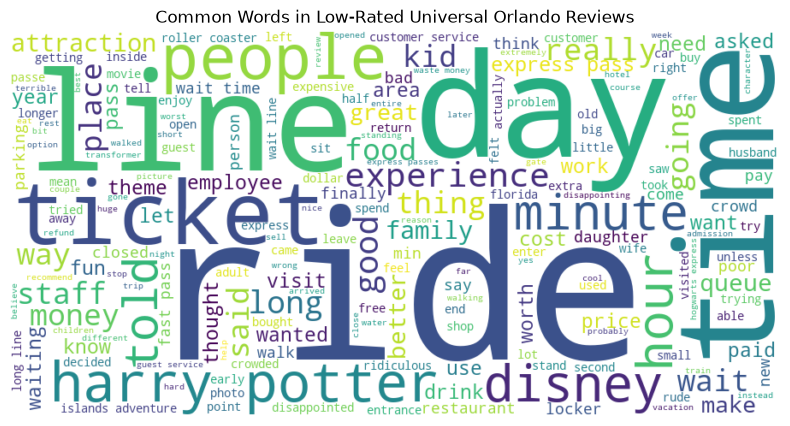

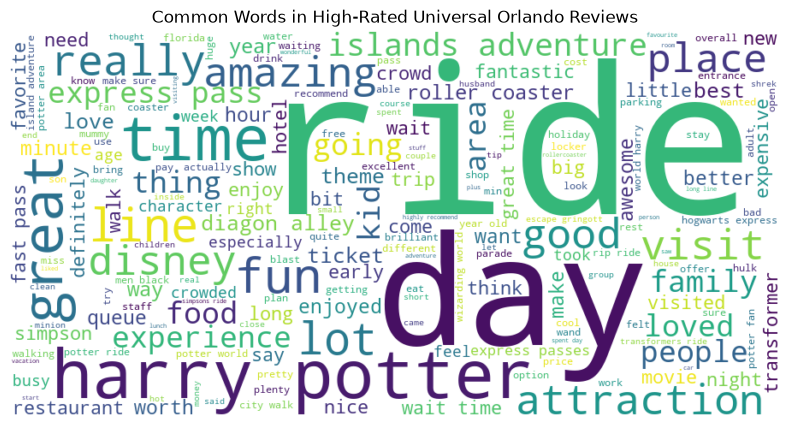

In [15]:
low_text = " ".join(
    comparison.loc[
        comparison["rating_group"] == "Low (1–2)",
        "clean_text"
    ]
)
high_text = " ".join(
    comparison.loc[
        comparison["rating_group"] == "High (4–5)",
        "clean_text"
    ]
)

low_cloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(low_text)

plt.figure(figsize=(10, 5))
plt.imshow(low_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Low-Rated Universal Orlando Reviews")
plt.show()

high_cloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(high_text)

plt.figure(figsize=(10, 5))
plt.imshow(high_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in High-Rated Universal Orlando Reviews")
plt.show()

**What is one apparent difference between the two word clouds?**

Your answer:The lower-rated word cloud can be seen with larger counts of "line", "time", and "ticket". Another noticeable difference that you can see is that the lower rated reviews talk more about money, cost, and the ticket.

**What is one limitation of using word clouds for this comparison?**

Your answer: The size of the word does not provide any context. This would be more effective if we worked with scikitLearn and used n-grams to collect each individual phrases to gather deeper insights of the data.

**After viewing the word clouds, recommend one additional stopword that could make the comparison more informative. Explain your choice.**

Your answer:A couple stop words could be, "ride", "harry", and "potter" because both word clouds share the same common topic.

## 10. Create word-frequency bar charts

Run the provided code. `frequency_frame()` counts every token in a selected rating group, keeps the 15 most frequent words, and sorts them from most to least frequent. With a horizontal Seaborn bar chart, this ordering places the most frequent word at the top.

The code creates separate figures for the Low and High rating groups. The tables are used to construct the figures but are not printed.

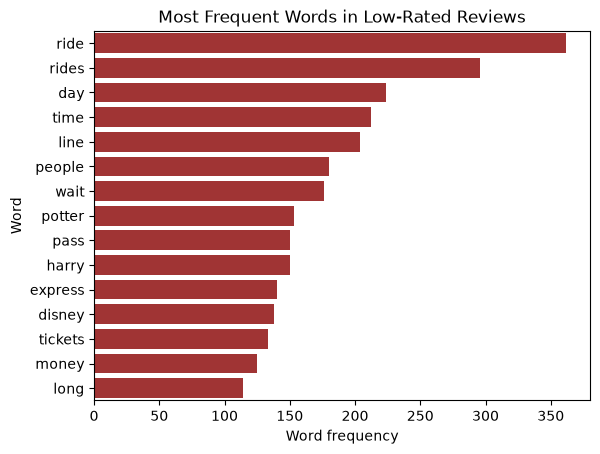

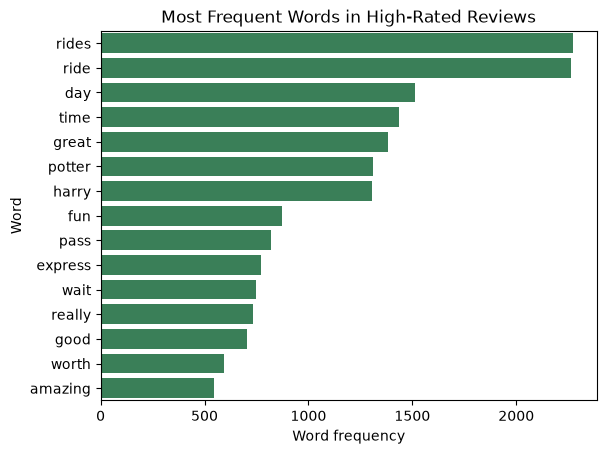

In [16]:
def frequency_frame(group, number_of_words=15):
    counts = Counter(
        word
        for tokens in comparison.loc[
            comparison["rating_group"] == group,
            "tokens"
        ]
        for word in tokens
    )
    return (
        pd.DataFrame(
            counts.most_common(number_of_words),
            columns=["word", "frequency"]
        )
        .sort_values("frequency", ascending=False)
    )


low_frequency = frequency_frame("Low (1–2)")
high_frequency = frequency_frame("High (4–5)")

sns.barplot(
    data=low_frequency,
    x="frequency",
    y="word",
    color="firebrick"
)
plt.title("Most Frequent Words in Low-Rated Reviews")
plt.xlabel("Word frequency")
plt.ylabel("Word")
plt.show()

sns.barplot(
    data=high_frequency,
    x="frequency",
    y="word",
    color="seagreen"
)
plt.title("Most Frequent Words in High-Rated Reviews")
plt.xlabel("Word frequency")
plt.ylabel("Word")
plt.show()

**What do the bar charts make easier to compare than the word clouds?**

Your answer:The words are lined up vertically and they do not intrude on other word space. This is easier to compare the most common words and also mistakes that could be corrected in the visual. 

**Which repeated words appear prominently in both groups?**

Your answer:Ride(s), day, and time.

## 11. Compare review lengths

Use `sns.boxplot()` to compare `review_length_words` across the Low and High rating groups. Use `order=["Low (1–2)", "High (4–5)"]`, choose a human-readable color, and add a descriptive title and axis labels.

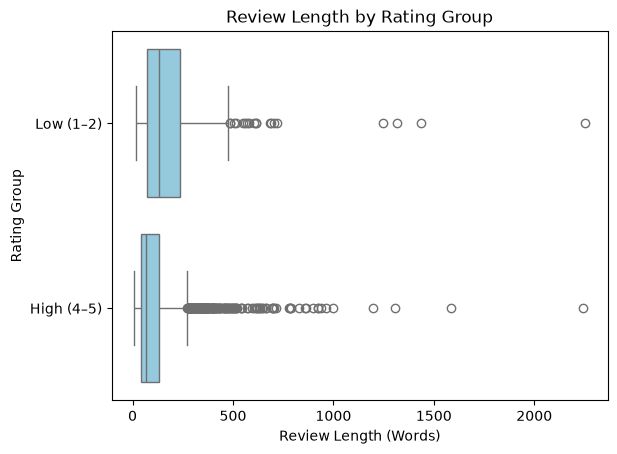

In [17]:
# Write your code here.
sns.boxplot(
    data=comparison,
    x = "review_length_words",
    y = "rating_group",
    order=["Low (1–2)", "High (4–5)"],
    color="skyblue"
    )

plt.title("Review Length by Rating Group")
plt.xlabel("Review Length (Words)")
plt.ylabel("Rating Group")
plt.show()

**How do the centers and variability of review length compare between the groups?**

Your answer: The center and variablility is that the length of higher rated reviews tend to have less words, and they have less variability ranging only between a couple words to 250 words and in the less common ranges past 2000 words.

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from the word-frequency and review-length figures.**

Your answer: High-rated reviews were generally shorter than low-rated reviews, with median lengths of 69 and 134 words, respectively. Both groups commonly used words such as “rides,” “time,” and “day,” showing that they discussed some similar topics despite their different ratings. These results show differences in review length, but word counts alone cannot explain why visitors gave particular ratings.

**Why do frequent words not necessarily identify the most important causes of a visitor's rating?**

Your answer: Frequent words do not necessarily identify the causes of a visitor’s rating because low- and high-rated reviews often share the same common words about the overall theme park experience.

**How might the historical time span limit conclusions about current Universal Studios Florida experiences?**

Your answer: The historical data may limit conclusions about the current conditions of Universal Studios Florida experience because the park could have changed since the time of the reviews being made. Some older reviews may not accurately represent the visitors' experiences today.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: I used AI for understanding why my wordcloud was not able to run (it was a mistake on how I used the hyphen when binning). Additionally I used AI to tighten up my conclusions and explanations.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give each figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Explain relevant limitations of the text and sample.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.

In [18]:
## For funsies
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_ngram_frequencies(text_series, ngram_range=(2, 3), min_df=2):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words="english",
        min_df=min_df
    )

    matrix = vectorizer.fit_transform(text_series.dropna())

    frequencies = matrix.sum(axis=0).A1
    phrases = vectorizer.get_feature_names_out()

    return dict(zip(phrases, frequencies))

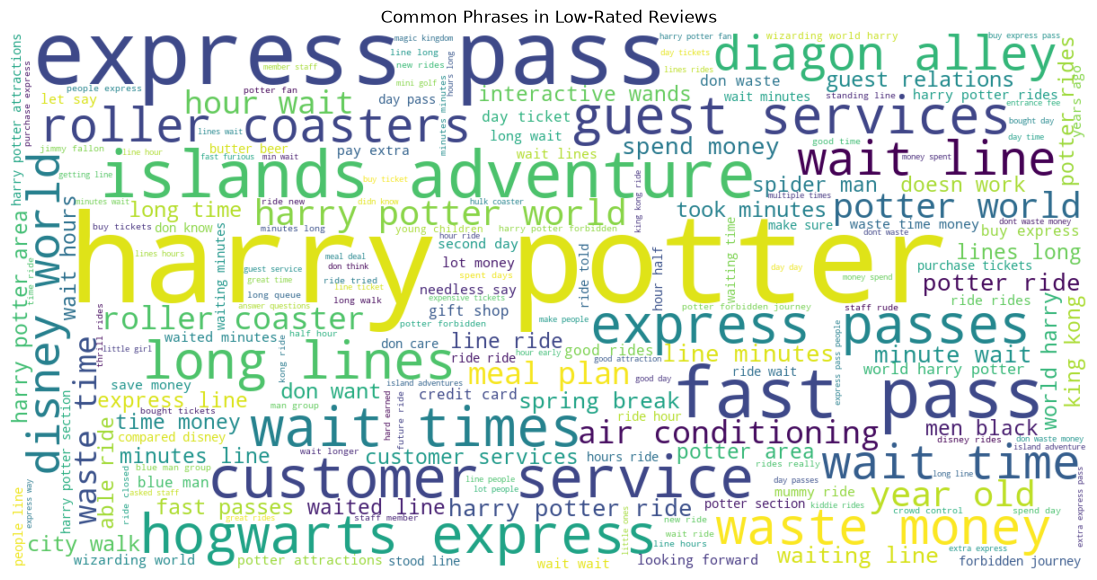

In [19]:
low_reviews = comparison.loc[
    comparison["rating_group"] == "Low (1–2)",
    "clean_text"
]

low_phrases = get_ngram_frequencies(
    low_reviews,
    ngram_range=(2, 3),
    min_df=2
)

low_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(low_phrases)

plt.figure(figsize=(14, 7))
plt.imshow(low_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Phrases in Low-Rated Reviews")
plt.show()

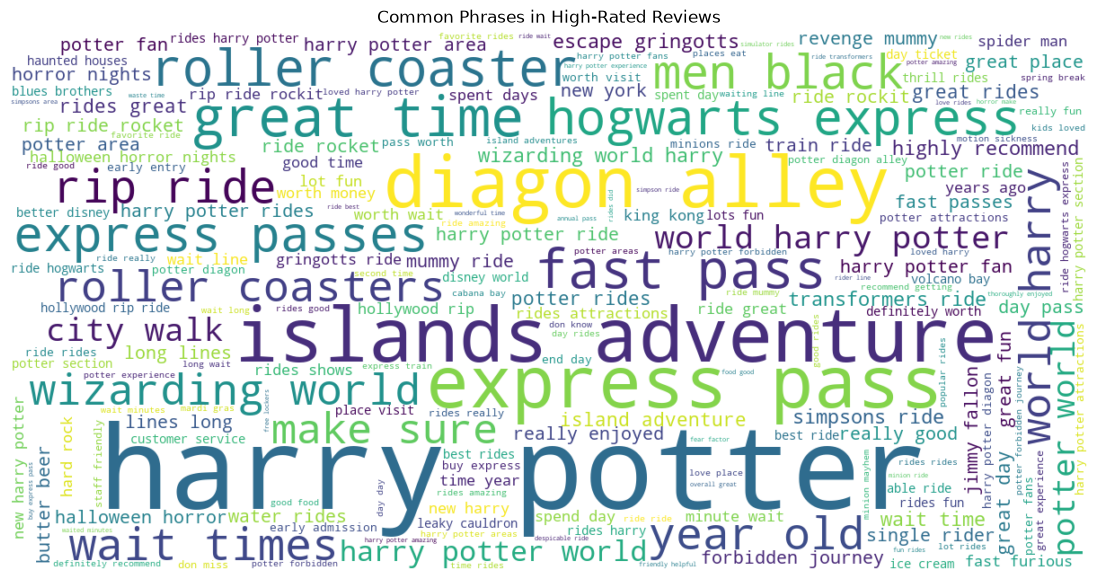

In [20]:
high_reviews = comparison.loc[
    comparison["rating_group"] == "High (4–5)",
    "clean_text"
]

high_phrases = get_ngram_frequencies(
    high_reviews,
    ngram_range=(2, 3),
    min_df=2
)

high_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(high_phrases)

plt.figure(figsize=(14, 7))
plt.imshow(high_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Phrases in High-Rated Reviews")
plt.show()

In [ ]:
## The most common phrases relying only on the cloud
sorted(low_phrases.items(), key=lambda x: x[1], reverse=True)[:20]

[('harry potter', np.int64(146)),
 ('express pass', np.int64(62)),
 ('fast pass', np.int64(36)),
 ('islands adventure', np.int64(31)),
 ('customer service', np.int64(24)),
 ('wait times', np.int64(22)),
 ('hogwarts express', np.int64(21)),
 ('express passes', np.int64(20)),
 ('guest services', np.int64(19)),
 ('long lines', np.int64(19)),
 ('waste money', np.int64(18)),
 ('diagon alley', np.int64(16)),
 ('roller coasters', np.int64(16)),
 ('wait line', np.int64(16)),
 ('wait time', np.int64(16)),
 ('disney world', np.int64(14)),
 ('harry potter world', np.int64(14)),
 ('potter world', np.int64(14)),
 ('year old', np.int64(14)),
 ('air conditioning', np.int64(13))]